In [ ]:
# In the lecture, we performed the ligand-based virtual screening (LBVS) for the target JAK2. In this coding project, you are asked to repeat the whole procedure to find the candidate molecules for the target IRAK4 (https://www.uniprot.org/uniprotkb/Q9NWZ3/entryLinks to an external site.). You need to upload the colab code and brief report discussing your procedure.

# We have noticed that the ZINC database keeps throwing a “502 proxy error”.Please utilize the ZINC library provided:

In this project, I applied the ligand-based virtual screening (LBVS) workflow introduced in the lecture to the IRAK4 target. First, IC50 data for IRAK4 were collected from the ChEMBL database, and the dataset was preprocessed to retain only the SMILES structures and pIC50 values. The molecular structures were then converted into ECFP4 fingerprints using RDKit so that they could be used as input for machine learning models. The generated fingerprints were used as input data (X), while the pIC50 values were used as target labels (y). The processed data were converted into PyTorch tensors and divided into training and test sets. A Fully Connected Neural Network (FCNN) was then constructed and trained to predict pIC50 values. MSE loss and the Adam optimizer were used during training, and the model performance was evaluated using MSE and R² score on the test set. In addition, a scatter plot comparing the true and predicted pIC50 values was generated to visually assess the prediction performance of the model.

After constructing and validating the FCNN model, the ZINC compound library was imported and used for virtual screening. The SMILES structures in the ZINC library were converted into ECFP4 fingerprints using the same procedure applied to the training dataset. These fingerprints were transformed into PyTorch tensors and provided as input to the trained FCNN model. The model predicted pIC50 values for all compounds in the library, and the prediction results were added to the dataset and ranked in descending order of predicted activity.
Next, the novelty of the candidate compounds was evaluated by calculating Tanimoto similarity scores between the candidate compounds and the molecules used in the training dataset. For each candidate, the maximum similarity value was recorded, and compounds with similarity values greater than or equal to 0.9 were removed because they were considered too similar to known molecules. This step helped identify candidate compounds that were structurally distinct from those already present in the training set.

The remaining candidates were then evaluated in terms of drug-likeness and synthetic accessibility. Quantitative Estimate of Drug-likeness (QED) scores were calculated to assess whether the compounds possessed favorable drug-like properties, while Synthetic Accessibility Scores (SAS) were calculated to estimate how easily the compounds could be synthesized in practice. The calculated QED and SAS values were added to the candidate dataset, allowing each compound to be evaluated based on predicted activity, novelty, drug-likeness, and synthetic feasibility.

Finally, compounds with QED values greater than 0.2 and SAS values lower than 4.5 were retained. The filtered compounds were ranked according to their predicted pIC50 values, and the top 10 compounds were selected as the final virtual screening hits for IRAK4. The final list of candidate compounds was exported as a CSV file for further analysis and future validation studies.

In [22]:
# ChEMBL_IRAK4_preprecessing

from google.colab import files

uploaded = files.upload()

Saving DOWNLOAD-Sb3YBownux7u3z58rYHh_234vu23q5cb_FWdoIlNy28_eq_.csv to DOWNLOAD-Sb3YBownux7u3z58rYHh_234vu23q5cb_FWdoIlNy28_eq_.csv


In [27]:
with open("DOWNLOAD-Sb3YBownux7u3z58rYHh_234vu23q5cb_FWdoIlNy28_eq_.csv", "r") as f:
    for i in range(10):
        print(f.readline())

"Molecule ChEMBL ID";"Molecule Name";"Molecule Max Phase";"Molecular Weight";"#RO5 Violations";"AlogP";"Compound Key";"Smiles";"Standard Type";"Standard Relation";"Standard Value";"Standard Units";"pChEMBL Value";"Data Validity Comment";"Comment";"Uo Units";"Ligand Efficiency BEI";"Ligand Efficiency LE";"Ligand Efficiency LLE";"Ligand Efficiency SEI";"Potential Duplicate";"Assay ChEMBL ID";"Assay Description";"Assay Type";"BAO Format ID";"BAO Label";"Assay Organism";"Assay Tissue ChEMBL ID";"Assay Tissue Name";"Assay Cell Type";"Assay Subcellular Fraction";"Assay Parameters";"Assay Variant Accession";"Assay Variant Mutation";"Target ChEMBL ID";"Target Name";"Target Organism";"Target Type";"Document ChEMBL ID";"Source ID";"Source Description";"Document Journal";"Document Year";"Cell ChEMBL ID";"Properties";"Action Type";"Standard Text Value";"Value"

"CHEMBL5958172";"";"None";"489.59";"0";"4.82";"BDBM209424";"CC(C)(O)[C@H](F)CNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc1NCC1CCCC1F";"IC50";"'='";"3.0";

In [28]:
# The data were displayed incorrectly when the file was read as a CSV file.

import pandas as pd

df = pd.read_csv(
    "DOWNLOAD-Sb3YBownux7u3z58rYHh_234vu23q5cb_FWdoIlNy28_eq_.csv",
    sep=";"
)

df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL5958172,NaN,NaN,489.59,0.0,4.82,BDBM209424,CC(C)(O)[C@H](F)CNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc...,IC50,'=',...,CHEMBL5725441,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,3.0
1,CHEMBL5756360,NaN,NaN,483.64,0.0,4.47,BDBM209629,CC(C)NC(=O)N[C@H](C)CCNC(=O)c1cnc(Nc2ccc3ncsc3...,IC50,'=',...,CHEMBL5725441,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,1.7
2,CHEMBL5870131,NaN,NaN,431.45,0.0,2.58,BDBM210146,CC(C)(O)C(F)(F)CNC(=O)c1cnc(Nc2ccc3nccn3n2)cc1...,IC50,'=',...,CHEMBL5725441,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,9.6
3,CHEMBL5985617,NaN,NaN,407.43,0.0,1.87,BDBM317433,Cn1cc2c(n1)C(=O)NCCOCCOc1cc(ccn1)-c1cccc(c1)C(...,IC50,'<',...,CHEMBL5726119,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,1000.0
4,CHEMBL6011144,NaN,NaN,496.59,0.0,3.09,BDBM317440,O=C1Nc2cn(C3CCOCC3)nc2C(=O)NCCCOCCCc2cc(ccn2)-...,IC50,'<',...,CHEMBL5726119,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,100.0


In [29]:
print(df.columns.tolist())

['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value']


In [30]:
# The data were preprocessed to keep only the SMILES and pIC50 columns, as done in the lecture.

import pandas as pd

df = pd.read_csv(
    "DOWNLOAD-Sb3YBownux7u3z58rYHh_234vu23q5cb_FWdoIlNy28_eq_.csv",
    sep=";"
)


df = df[["Smiles", "pChEMBL Value"]]

df.columns = ["SMILES", "pIC50"]

df = df.dropna()

print(df.shape)
df.head()

(8654, 2)


,SMILES,pIC50
0,CC(C)(O)[C@H](F)CNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc...,8.52
1,CC(C)NC(=O)N[C@H](C)CCNC(=O)c1cnc(Nc2ccc3ncsc3...,8.77
2,CC(C)(O)C(F)(F)CNC(=O)c1cnc(Nc2ccc3nccn3n2)cc1...,8.02
9,COc1cc2c(OC[C@@H]3NC(=O)[C@H](F)C34CC4)nccc2cc...,5.84
10,N#Cc1ccc2ncnc(N[C@H]3CC[C@H](N4CCOCC4)CC3)c2c1,8.15


In [32]:
# Save

df.to_csv("IRAK4_pIC50.csv", index=False)

In [33]:
# Download

from google.colab import files

files.download("IRAK4_pIC50.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**The workflow used in the lecture was applied to IRAK4.**

In [2]:
# Install rdkit

!pip install rdkit==2024.3.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 29.0 MB/s eta 0:00:00


In [13]:
# import rdkit

import rdkit
import rdkit.Chem as Chem
from rdkit.Chem import AllChem, DataStructs

In [14]:
# import pandas & numpy

import copy
from IPython.display import display   # for dsisplaying table

import pandas as pd   # handling tables
import numpy as np    # numpy



In [15]:
# import pytorch

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

**File uploading and reading**

1. ChEMBL_IRAK4_IC50.csv

2. ZINC_compound_library.csv

In [41]:
# Read a csv file into DataFrame

IRAK4_dataframe=pd.read_csv('ChEMBL_IRAK4_IC50.csv')

IRAK4_dataframe

,SMILES,pIC50
0,CC(C)(O)[C@H](F)CNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc...,8.52
1,CC(C)NC(=O)N[C@H](C)CCNC(=O)c1cnc(Nc2ccc3ncsc3...,8.77
2,CC(C)(O)C(F)(F)CNC(=O)c1cnc(Nc2ccc3nccn3n2)cc1...,8.02
3,COc1cc2c(OC[C@@H]3NC(=O)[C@H](F)C34CC4)nccc2cc...,5.84
4,N#Cc1ccc2ncnc(N[C@H]3CC[C@H](N4CCOCC4)CC3)c2c1,8.15
...,...,...
8649,Cn1c(=O)n(C2CCC(=O)NC2=O)c2cccc(C#CCOC3(C)CCN(...,6.77
8650,CC(C)Oc1cc2c(OC[C@@H]3COC(=O)N3)nccc2cc1C(N)=O,8.18
8651,CC(C)Oc1cc2c(OCC3COCC(=O)N3)nccc2cc1C(N)=O,6.84
8652,CC(C)Oc1cc2c(OC[C@]3(C)CCC(=O)N3)nccc2cc1C(N)=O,7.38


In [40]:
# IRAK4_dataframe

In [44]:
# @title let's take a look at IRAK4_IC50

num_data, num_col = IRAK4_dataframe.shape

print(f"Num data: {num_data}")
print(f"Num columns: {num_col}")

print(f"Dataframe columns: {IRAK4_dataframe.columns.tolist()}")

print("1st row:")
print(IRAK4_dataframe.iloc[0])

print(f"last smiles: {IRAK4_dataframe['SMILES'].iloc[-1]}")
print(f"last pIC50: {IRAK4_dataframe['pIC50'].iloc[-1]}")

Num data: 8654
Num columns: 2
Dataframe columns: ['SMILES', 'pIC50']
1st row:
SMILES    CC(C)(O)[C@H](F)CNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc...
pIC50                                                  8.52
Name: 0, dtype: object
last smiles: COc1cc2c(OC[C@H]3CN(C)C(=O)O3)nccc2cc1C(N)=O
last pIC50: 5.93


In [45]:
# @title Create list

smiles_list = list(IRAK4_dataframe["SMILES"])
pIC50_list = list(IRAK4_dataframe["pIC50"])

In [46]:
# @title first three elements

print("smiles_list")
print(smiles_list[:3])

print("\npIC50_list")
print("pIC50_list[:3}]")

smiles_list
['CC(C)(O)[C@H](F)CNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc1NCC1CCCC1F', 'CC(C)NC(=O)N[C@H](C)CCNC(=O)c1cnc(Nc2ccc3ncsc3c2)cc1NC(C)C', 'CC(C)(O)C(F)(F)CNC(=O)c1cnc(Nc2ccc3nccn3n2)cc1NC1CC1']

pIC50_list
pIC50_list[:3}]


In [ ]:
#@title Featurization





In [47]:
#@title descriptor ECFP

ecfp_list=[]
for smi in smiles_list:
  mol=Chem.MolFromSmiles(smi)

  fpgen=AllChem.GetMorganGenerator(radius=2, fpSize=1024)
  fp=fpgen.GetFingerprint(mol)

  fp=np.array(fp)
  ecfp_list.append(fp)

print(len(ecfp_list))
print(ecfp_list[0])

8654
[0 1 0 ... 0 1 0]


In [57]:
#@title convert into pytorch tensors

X = np.array(ecfp_list)
X = torch.from_numpy(X).float()

# y= target = pIC50

y = np.array(pIC50_list)
y = torch.from_numpy(y).float()

In [58]:
# @title Shape

print(f"X:{X.shape}")
print(f"y:{y.shape}\n")

# first 4 data

print(f"X: {X[:4].shape}")
print(X[:4])

print(f"y: {y[:4].shape}")
print(y[:4])


X:torch.Size([8654, 1024])
y:torch.Size([8654])

X: torch.Size([4, 1024])
tensor([[0., 1., 0.,  ..., 0., 1., 0.],
        [0., 1., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
y: torch.Size([4])
tensor([8.5200, 8.7700, 8.0200, 5.8400])


In [60]:
# @title split into train set and test set

from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.1, random_state=42)

# train data: 8654 * 0.9 = 7788.6 --> 7788
# test data: 8654 - 7789 = 866

print(f"train X: {train_X.shape}")
print(f"test X: {test_X.shape}")

print(f"train y: {train_y.shape}")
print(f"test y: {test_y.shape}")

train X: torch.Size([7788, 1024])
test X: torch.Size([866, 1024])
train y: torch.Size([7788])
test y: torch.Size([866])


**FCNN model**

In [62]:
#@title sequential model

model = nn.Sequential(
    nn.Linear(1024, 64),    # first layer
    nn.ReLU(),              # activation function
    nn.Linear(64, 32),      # second layer
    nn.ReLU(),
    nn.Linear(32, 1)        # third layer
)

print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [64]:
# parameters

for name, param in model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([64, 1024])
0.bias torch.Size([64])
2.weight torch.Size([32, 64])
2.bias torch.Size([32])
4.weight torch.Size([1, 32])
4.bias torch.Size([1])


In [65]:
# parameters before training

print(f"Layer 3 weight:")
print(model[4].weight)

Layer 3 weight:
Parameter containing:
tensor([[-0.0953,  0.0796,  0.1127, -0.0952, -0.0128, -0.0362,  0.0784,  0.1471,
          0.0599,  0.0553,  0.1222, -0.0674,  0.1345,  0.0900, -0.1586, -0.1268,
          0.0346,  0.0681,  0.0904, -0.0853,  0.1361, -0.0922, -0.1128,  0.0157,
         -0.1511, -0.0818,  0.1054, -0.0247, -0.0418,  0.1196,  0.1237,  0.0632]],
       requires_grad=True)


In [72]:
#@title Create model using class

class FCNN(nn.Module):
  def __init__(self):
        super(FCNN, self).__init__()

        self.fc1 = nn.Linear(1024, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

  def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FCNN()

print(model)

FCNN(
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [73]:
#@title Parameters
for name, param in model.named_parameters():
    print(name, param.shape)


fc1.weight torch.Size([64, 1024])
fc1.bias torch.Size([64])
fc2.weight torch.Size([32, 64])
fc2.bias torch.Size([32])
fc3.weight torch.Size([1, 32])
fc3.bias torch.Size([1])


**Model training**

In [74]:
#@ title choose loss function and optimizer

loss_fn = nn.MSELoss()                                  # loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4)     # optimizer & learning rate = 1e-4

In [75]:
#@title model training

n_epochs = 40
batch_size = 64

train_loss = []    # to save train loss at each epoch

model.train()      # set the model to training mode

for epoch in range(n_epochs):

    loss_list = []

    for i in range(0, len(train_X), batch_size):

        X_batch = train_X[i:i+batch_size]
        y_batch = train_y[i:i+batch_size]

        # make prediction and reshape
        y_pred = model(X_batch)               # shape: [[y1_pred], [y2_pred], ...]
        y_pred = y_pred.reshape(y_batch.shape) # shape: [y1_pred, y2_pred, ...]

        loss = loss_fn(y_pred, y_batch)       # loss

        optimizer.zero_grad()                 # initialize gradients
        loss.backward()                       # compute gradients
        optimizer.step()                      # model update

        loss_list.append(loss.item())         # save loss

    epoch_loss = np.mean(np.array(loss_list))

    train_loss.append(epoch_loss)

    print(f"Epoch {epoch}, loss {epoch_loss:.5f}")

Epoch 0, loss 52.25617
Epoch 1, loss 19.51920
Epoch 2, loss 1.72362
Epoch 3, loss 1.12788
Epoch 4, loss 1.00292
Epoch 5, loss 0.90731
Epoch 6, loss 0.83398
Epoch 7, loss 0.77743
Epoch 8, loss 0.73318
Epoch 9, loss 0.69744
Epoch 10, loss 0.66736
Epoch 11, loss 0.64134
Epoch 12, loss 0.61809
Epoch 13, loss 0.59744
Epoch 14, loss 0.57916
Epoch 15, loss 0.56273
Epoch 16, loss 0.54843
Epoch 17, loss 0.53557
Epoch 18, loss 0.52386
Epoch 19, loss 0.51313
Epoch 20, loss 0.50314
Epoch 21, loss 0.49377
Epoch 22, loss 0.48478
Epoch 23, loss 0.47593
Epoch 24, loss 0.46697
Epoch 25, loss 0.45746
Epoch 26, loss 0.44771
Epoch 27, loss 0.43800
Epoch 28, loss 0.42831
Epoch 29, loss 0.41876
Epoch 30, loss 0.40944
Epoch 31, loss 0.40039
Epoch 32, loss 0.39100
Epoch 33, loss 0.38194
Epoch 34, loss 0.37311
Epoch 35, loss 0.36443
Epoch 36, loss 0.35607
Epoch 37, loss 0.34779
Epoch 38, loss 0.33980
Epoch 39, loss 0.33191


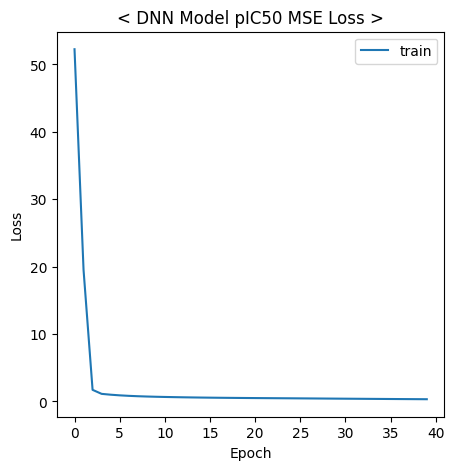

In [76]:
# @title plot loss

import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.plot(train_loss, label='train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('< DNN Model pIC50 MSE Loss >')
plt.show()

**Model evaluation**

In [77]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [79]:
#@title compute loss on train set

with torch.no_grad():
    train_pred = model(train_X)
    train_pred = train_pred.reshape(train_y.shape)
    loss = loss_fn(train_pred, train_y)
    print(f"Train Loss: {loss:.3f}")

    test_pred = model(test_X)
    test_pred = test_pred.reshape(test_y.shape)
    loss = loss_fn(test_pred, test_y)
    print(f"Test Loss: {loss:.3f}")

Train Loss: 0.322
Test Loss: 0.493


In [81]:
#@title r2 score and MSE on test set

with torch.no_grad():
  test_pred = model(test_X)
  r2_test = r2_score(test_y, test_pred)
  mse_test = mean_squared_error(test_y, test_pred)

print('Evaluation on Test Set')
print(f"  R2 score: {r2_test:.3f}")
print(f"  MSE: {mse_test:.3f}")

Evaluation on Test Set
  R2 score: 0.624
  MSE: 0.493


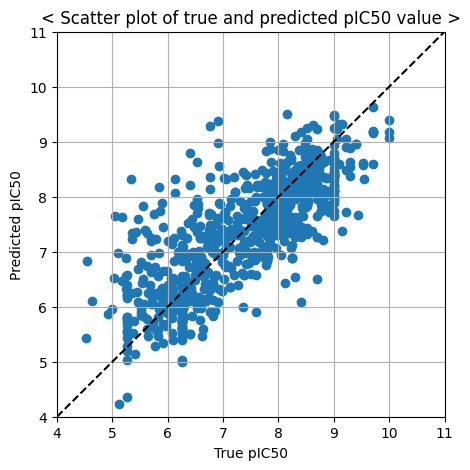

In [82]:
#@title plot

plt.figure(figsize=(5,5))

plt.scatter(test_y, test_pred)

plt.xlabel('True pIC50')
plt.ylabel('Predicted pIC50')

plt.grid()

plt.xlim(4, 11)
plt.ylim(4, 11)

plt.plot(range(4, 12), range(4, 12), 'k--', label='y=x')

plt.title('< Scatter plot of true and predicted pIC50 value >')

plt.show()

**2. Virtual screening**

In [85]:
#@title Read a comma-separated values(csv)file into Dataframe

ZINC_dataframe=pd.read_csv('/content/ZINC_compound_library_file.csv')

display(ZINC_dataframe)

,zinc_id,smiles
0,ZINC000023247639,CCN1CCN(Cc2ccc(NC(=O)Nc3ccc(Oc4cc(NC)ncn4)cc3)...
1,ZINC000003964325,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F...
2,ZINC000004793192,CCN1/C(=C/C(C)=O)Sc2ccc(OC)cc21
3,ZINC000018825344,Cc1[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c(C)c1C(=O)N...
4,ZINC000211266712,COc1cccc(C(=O)Nc2nc3cc4c(cc3[nH]2)OC(F)(F)O4)c1
...,...,...
78309,ZINC000040935360,Nc1[nH]nc2ccc(-c3cc[nH]n3)cc12
78310,ZINC000299856072,COc1cccc(NC(=O)c2cnc(N3CCN(c4ccccc4OC)CC3)c([N...
78311,ZINC000103271379,O=C1NC(=O)C(c2c[nH]c3ccccc23)=C1Nc1ccc(OCCNc2c...
78312,ZINC000003874496,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O


In [86]:
#@ title converts smiles column into list

zinc_smiles_list = list(ZINC_dataframe["smiles"])
zinc_smiles_list[:3]

['CCN1CCN(Cc2ccc(NC(=O)Nc3ccc(Oc4cc(NC)ncn4)cc3)cc2C(F)(F)F)CC1',
 'CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',
 'CCN1/C(=C/C(C)=O)Sc2ccc(OC)cc21']

In [87]:
#@title get ECFP vectors

vs_ecfp_list = []

for smiles in zinc_smiles_list:

    mol = Chem.MolFromSmiles(smiles)

    # if mol is None, pass the below code and continue the for loop.
    if mol == None:
        continue

    # Generate fingerprint
    fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
    fp = fpgen.GetFingerprint(mol)

    # Convert fingerprint to numpy array.
    fp = np.array(fp)

    # append fp to vs_ecfp_list
    vs_ecfp_list.append(fp)

print(f"vs_ecfp_list: {len(vs_ecfp_list)}")
print(f"ecfp sample: {fp}")

vs_ecfp_list: 78314
ecfp sample: [0 1 0 ... 0 0 0]


In [88]:
#@title convert into pytorch tensors

vs_X = np.array(vs_ecfp_list)
vs_X = torch.from_numpy(vs_X).float()
print(f"vs_X: {vs_X.shape}")

vs_X: torch.Size([78314, 1024])


In [89]:
#@title predict pIC50 values

pIC50_predict = []

model.eval()
with torch.no_grad():
    vs_pred = model(vs_X)

print(f"vs_pred shape: {vs_pred.shape}")
print(vs_pred)
vs_pred = vs_pred.squeeze(1).numpy()
print(vs_pred)

vs_pred shape: torch.Size([78314, 1])
tensor([[6.4154],
        [5.3932],
        [3.9858],
        ...,
        [5.9058],
        [5.0995],
        [5.6507]])
[6.4153748 5.3931923 3.985798  ... 5.9057713 5.0994873 5.650749 ]


In [90]:
#@ title create a new column

ZINC_dataframe["pIC50_pred"] = vs_pred
ZINC_dataframe

,zinc_id,smiles,pIC50_pred
0,ZINC000023247639,CCN1CCN(Cc2ccc(NC(=O)Nc3ccc(Oc4cc(NC)ncn4)cc3)...,6.415375
1,ZINC000003964325,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F...,5.393192
2,ZINC000004793192,CCN1/C(=C/C(C)=O)Sc2ccc(OC)cc21,3.985798
3,ZINC000018825344,Cc1[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c(C)c1C(=O)N...,5.538545
4,ZINC000211266712,COc1cccc(C(=O)Nc2nc3cc4c(cc3[nH]2)OC(F)(F)O4)c1,5.529914
...,...,...,...
78309,ZINC000040935360,Nc1[nH]nc2ccc(-c3cc[nH]n3)cc12,3.509546
78310,ZINC000299856072,COc1cccc(NC(=O)c2cnc(N3CCN(c4ccccc4OC)CC3)c([N...,6.049541
78311,ZINC000103271379,O=C1NC(=O)C(c2c[nH]c3ccccc23)=C1Nc1ccc(OCCNc2c...,5.905771
78312,ZINC000003874496,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,5.099487


In [91]:
# @title sorting

ZINC_dataframe = ZINC_dataframe.sort_values(by=['pIC50_pred'], ascending=False)
ZINC_dataframe

,zinc_id,smiles,pIC50_pred
62797,ZINC000095615148,COc1cc(N2CCC(N3C[C@H](C)O[C@H](C)C3)CC2)ccc1Nc...,11.230533
32521,ZINC000049898153,COc1cc(N2CCC(N3CCCCC3)CC2)ccc1Nc1nccc(-c2c(-c3...,11.130766
62766,ZINC000049898153,COc1cc(N2CCC(N3CCCCC3)CC2)ccc1Nc1nccc(-c2c(-c3...,11.130766
57613,ZINC000095615196,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F...,11.129611
67782,ZINC000095615196,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F...,11.129611
...,...,...,...
63406,ZINC000103236201,Cc1c(O)c(O)c(O)c2c1COC2=O,0.988414
50949,ZINC000006920405,OC[C@H]1O[C@@](CO)(O[C@H]2O[C@H](CO[C@H]3O[C@H...,0.873053
50957,ZINC000040164424,OC[C@H]1O[C@@](CO)(O[C@@H]2O[C@H](CO[C@@H]3O[C...,0.873053
50959,ZINC000040164426,OC[C@H]1O[C@@](CO)(O[C@H]2O[C@H](CO[C@@H]3O[C@...,0.873053


In [92]:
#@title select top 200 compounds

candidates = ZINC_dataframe.head(200)
candidates

,zinc_id,smiles,pIC50_pred
62797,ZINC000095615148,COc1cc(N2CCC(N3C[C@H](C)O[C@H](C)C3)CC2)ccc1Nc...,11.230533
32521,ZINC000049898153,COc1cc(N2CCC(N3CCCCC3)CC2)ccc1Nc1nccc(-c2c(-c3...,11.130766
62766,ZINC000049898153,COc1cc(N2CCC(N3CCCCC3)CC2)ccc1Nc1nccc(-c2c(-c3...,11.130766
57613,ZINC000095615196,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F...,11.129611
67782,ZINC000095615196,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F...,11.129611
...,...,...,...
77658,ZINC000299831796,Cc1ccc(Cl)cc1-c1[nH]c(-c2ccnc(Nc3ccc(N4CCN(C)C...,8.957971
62839,ZINC000072139953,COc1cc(N2CCN(C(N)=O)CC2)ccc1Nc1ncc(Cl)c(-c2cnc...,8.957036
63089,ZINC000072178454,COc1cc(N2CCN(C(C)=O)CC2)ccc1Nc1ncc(Cl)c(-c2cnc...,8.953289
62794,ZINC000049889315,O=C(Nc1c(F)cccc1F)c1cccc(-c2nc3ccccn3c2-c2ccnc...,8.947241


In [97]:
#@title remove molecules that are too similar to the molecules in training set

# ECFP from SMILES for candidate compounds
candidate_fingerprints = []

for smiles in candidates['smiles']:
    mol = Chem.MolFromSmiles(smiles)               # SMILES -> Mol
    fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
    fp = fpgen.GetFingerprint(mol)                 # Mol -> ECFP
    candidate_fingerprints.append(fp)

# ECFP from SMILES for original ligands
trainset_fingerprints = []

for smiles in IRAK4_dataframe['SMILES']:
    mol = Chem.MolFromSmiles(smiles)               # SMILES -> Mol
    fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
    fp = fpgen.GetFingerprint(mol)                 # Mol -> ECFP
    trainset_fingerprints.append(fp)

print(len(trainset_fingerprints))

8654


In [98]:
#@title calculate maximum similarity

from rdkit import DataStructs

sims = []

for x in candidate_fingerprints:

    max_similarity = -9999

    for y in trainset_fingerprints:

        similarity = DataStructs.TanimotoSimilarity(x, y)

        if max_similarity < similarity:
            max_similarity = similarity

    sims.append(max_similarity)

In [99]:
#@ title create a new dataframe column
candidates["max_tanimoto_similarity"]=sims
candidates

/tmp/ipykernel_1886/3450256786.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates["max_tanimoto_similarity"]=sims


,zinc_id,smiles,pIC50_pred,max_tanimoto_similarity
62797,ZINC000095615148,COc1cc(N2CCC(N3C[C@H](C)O[C@H](C)C3)CC2)ccc1Nc...,11.230533,0.324324
32521,ZINC000049898153,COc1cc(N2CCC(N3CCCCC3)CC2)ccc1Nc1nccc(-c2c(-c3...,11.130766,0.327103
62766,ZINC000049898153,COc1cc(N2CCC(N3CCCCC3)CC2)ccc1Nc1nccc(-c2c(-c3...,11.130766,0.327103
57613,ZINC000095615196,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F...,11.129611,0.288000
67782,ZINC000095615196,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F...,11.129611,0.288000
...,...,...,...,...
77658,ZINC000299831796,Cc1ccc(Cl)cc1-c1[nH]c(-c2ccnc(Nc3ccc(N4CCN(C)C...,8.957971,0.329412
62839,ZINC000072139953,COc1cc(N2CCN(C(N)=O)CC2)ccc1Nc1ncc(Cl)c(-c2cnc...,8.957036,0.355556
63089,ZINC000072178454,COc1cc(N2CCN(C(C)=O)CC2)ccc1Nc1ncc(Cl)c(-c2cnc...,8.953289,0.329787
62794,ZINC000049889315,O=C(Nc1c(F)cccc1F)c1cccc(-c2nc3ccccn3c2-c2ccnc...,8.947241,0.336735


In [100]:
#@title create a new copy of the filtered dataframe

filtered_candidates = candidates[candidates.max_tanimoto_similarity<0.9].copy(deep=True)

In [104]:
#@title calculate QED

from rdkit.Chem import QED

qed_list=[]

for smiles in filtered_candidates["smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    qed = QED.default(mol)
    qed_list.append(qed)
    print(f"QED: {qed:.5f}")

QED: 0.15326
QED: 0.15476
QED: 0.15476
QED: 0.14289
QED: 0.14289
QED: 0.14289
QED: 0.14289
QED: 0.14289
QED: 0.14289
QED: 0.14289
QED: 0.14289
QED: 0.16287
QED: 0.15668
QED: 0.15771
QED: 0.16292
QED: 0.16366
QED: 0.13327
QED: 0.13327
QED: 0.13327
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.16302
QED: 0.20809
QED: 0.20809
QED: 0.00795
QED: 0.00795
QED: 0.00795
QED: 0.00795
QED: 0.14657
QED: 0.14657
QED: 0.23756
QED: 0.23756
QED: 0.19478
QED: 0.19478
QED: 0.16716
QED: 0.16716
QED: 0.25557
QED: 0.21251
QED: 0.21251
QED: 0.21251
QED: 0.21251
QED: 0.21251
QED: 0.21251
QED: 0.05263
QED: 0.05263
QED: 0.39348
QED: 0.16055
QED: 0.16055
QED: 0.26478
QED: 0.26215
QED: 0.28742
QED: 0.03260
QED: 0.23606
QED: 0.23606
QED: 0.22614
QED: 0.22614
QED: 0.06777
QED: 0.24243
QED: 0.23455
QED: 0.23455
QED: 0.11016
QED: 0.22002
QED: 0.22002
QED: 0.17031
QED: 0.03461
QED: 0.35647
QED: 0.12534
QED: 0.12534
QED: 0.12534
QED: 0.03072
QED: 0.24381

In [105]:
#@title SAS

import sys
import os
from rdkit.Chem import RDConfig

sys.path.append(
    os.path.join(RDConfig.RDContribDir, "SA_Score")
)

import sascorer

sa_list = []

for smiles in filtered_candidates["smiles"]:

    mol = Chem.MolFromSmiles(smiles)

    sa_score = sascorer.calculateScore(mol)

    sa_list.append(sa_score)

    print(f"SA score: {sa_score:.5f}")

SA score: 3.93880
SA score: 3.09730
SA score: 3.09730
SA score: 3.42890
SA score: 3.42890
SA score: 3.42890
SA score: 3.42890
SA score: 3.42890
SA score: 3.42890
SA score: 3.42890
SA score: 3.42890
SA score: 3.21382
SA score: 3.63829
SA score: 3.07087
SA score: 3.13680
SA score: 3.15468
SA score: 3.51139
SA score: 3.51139
SA score: 3.51139
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.27927
SA score: 3.11464
SA score: 3.11464
SA score: 5.04799
SA score: 5.04799
SA score: 5.04799
SA score: 5.04799
SA score: 2.82897
SA score: 2.82897
SA score: 3.17634
SA score: 3.17634
SA score: 2.93561
SA score: 2.93561
SA score: 2.98674
SA score: 2.98674
SA score: 3.38568
SA score: 2.99602
SA score: 2.99602
SA score: 2.99602
SA score: 2.99602
SA score: 2.99602
SA score: 2.99602
SA score: 4.30680
SA score: 4.30680
SA score: 3.54554
SA score: 2.97587
SA score: 2.97587
SA score: 3.00991
SA score: 

In [106]:
# @title create QED & SA columns
filtered_candidates['QED'] = qed_list
filtered_candidates['SA'] = sa_list
filtered_candidates
filtered_candidates.describe()

,pIC50_pred,max_tanimoto_similarity,QED,SA
count,200.000000,200.000000,200.000000,200.000000
mean,9.548157,0.321537,0.226615,3.155135
std,0.627261,0.041156,0.100882,0.530729
min,8.945758,0.248000,0.007947,2.526230
25%,9.094160,0.293651,0.157455,2.827765
50%,9.329411,0.321839,0.212510,2.995463
75%,9.865028,0.339668,0.285667,3.279274
max,11.230533,0.695122,0.451505,5.047993


In [107]:
#@title filtering and select top 10 compounds

# filtering 1: QED > 0.2
cond1 = filtered_candidates['QED'] > 0.2

# filtering 2: SA score < 4.5
cond2 = filtered_candidates['SA'] < 4.5

my_candidates = filtered_candidates[cond1 & cond2].head(10).copy(deep=True)
display(my_candidates)

,zinc_id,smiles,pIC50_pred,max_tanimoto_similarity,QED,SA
49678,ZINC000044351173,COc1cc2c(cc1Nc1nc(Nc3cccc(F)c3C(N)=O)c3cc[nH]c...,10.252612,0.306306,0.208094,3.114639
62791,ZINC000044351173,COc1cc2c(cc1Nc1nc(Nc3cccc(F)c3C(N)=O)c3cc[nH]c...,10.252612,0.306306,0.208094,3.114639
49580,ZINC000044404856,COc1cc2c(cc1Nc1nc(Nc3cccc(F)c3C(N)=O)c3cc[nH]c...,9.923569,0.323810,0.237557,3.176336
63068,ZINC000044404856,COc1cc2c(cc1Nc1nc(Nc3cccc(F)c3C(N)=O)c3cc[nH]c...,9.923569,0.323810,0.237557,3.176336
70952,ZINC000049777869,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(/C=C/N4CNc5c(NC6CC...,9.909192,0.311111,0.255567,3.385680
18871,ZINC000049872011,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nc5ccccc5n4-c4c...,9.880263,0.290323,0.212510,2.996024
34434,ZINC000049872011,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nc5ccccc5n4-c4c...,9.880263,0.290323,0.212510,2.996024
74004,ZINC000049872011,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nc5ccccc5n4-c4c...,9.880263,0.290323,0.212510,2.996024
59398,ZINC000049872011,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nc5ccccc5n4-c4c...,9.880263,0.290323,0.212510,2.996024
8380,ZINC000049872011,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nc5ccccc5n4-c4c...,9.880263,0.290323,0.212510,2.996024


In [108]:
#@title save file "my_candidates.csv"

my_candidates.to_csv("my_candidates.csv", index=False)